#Machine Learning -Customer Revenue Prediction


In [1]:
import sys 
import os

sys.path.insert(0,os.path.abspath(".."))

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
file_path="../data/raw/online_retail_II.xlsx" 
excel_data=pd.read_excel(
    file_path,
    sheet_name=None
)

excel_data.keys()

dict_keys(['Year 2009-2010', 'Year 2010-2011'])

In [4]:
df=pd.concat(
    excel_data.values(),
    ignore_index=True
)

In [5]:
df.head()
df.tail()
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
957331,573769,22469,HEART OF WICKER SMALL,24,2011-11-01 10:04:00,1.65,13292.0,United Kingdom
1035295,579408,21642,ASSORTED TUTTI FRUTTI PEN,1,2011-11-29 12:34:00,0.29,14701.0,United Kingdom
15049,490667,90002A,FLOWER BURST SILVER RING OPAL,1,2009-12-07 12:32:00,3.75,13234.0,United Kingdom
720295,553673,23284,DOORMAT KEEP CALM AND COME IN,20,2011-05-18 12:46:00,6.75,16814.0,United Kingdom
275928,516189,20725,LUNCH BAG RED SPOTTY,20,2010-07-18 15:56:00,1.65,12625.0,Germany


In [6]:
df.describe()
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [7]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [8]:
missing=df.isnull().sum()
missing

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
missing_percentage=(
    df.isnull().mean()*100
).sort_values(ascending=False)
missing_percentage

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [10]:
missing_report=pd.DataFrame({
    "missing_count":df.isnull().sum(),
    "missing_percentage":df.isnull().mean()*100
})
missing_report=missing_report.sort_values(
    "missing_percentage",
    ascending=False
)
missing_report

,missing_count,missing_percentage
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [11]:
duplicate_count=df.duplicated().sum()
duplicate_count

np.int64(34335)

In [12]:
duplicate_percentage=(
    df.duplicated().mean()*100
)
duplicate_percentage

np.float64(3.2167821685243467)

In [13]:
df.nunique().sort_values()

Country           43
Quantity        1057
Price           2807
StockCode       5305
Description     5698
Customer ID     5942
InvoiceDate    47635
Invoice        53628
dtype: int64

In [14]:
df["Country"].nunique()
df["Country"].value_counts().head(20)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Finland              1049
Austria               938
Denmark               817
Unspecified           756
Greece                663
Name: count, dtype: int64

In [15]:
df["StockCode"].nunique()
df["Customer ID"].nunique()
df["Invoice"].nunique()

53628

In [16]:
df["Invoice"].astype(str).str.startswith("C").value_counts()
cancelled=df[
    df["Invoice"].astype(str).str.startswith("C")
]
cancelled.shape
cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [17]:
(df["Quantity"]<0).sum()
df[df["Quantity"]<0].head()
(df["Price"]<0).sum()

np.int64(5)

In [18]:
df["InvoiceDate"].min()
df["InvoiceDate"].max()
df["InvoiceDate"].isna().sum()


np.int64(0)

In [19]:
df["Revenue"]=df["Quantity"]*df["Price"]
df[["Quantity","Price","Revenue"]].head()
df["Revenue"].describe()
df["Revenue"].sum()

np.float64(19287250.568)

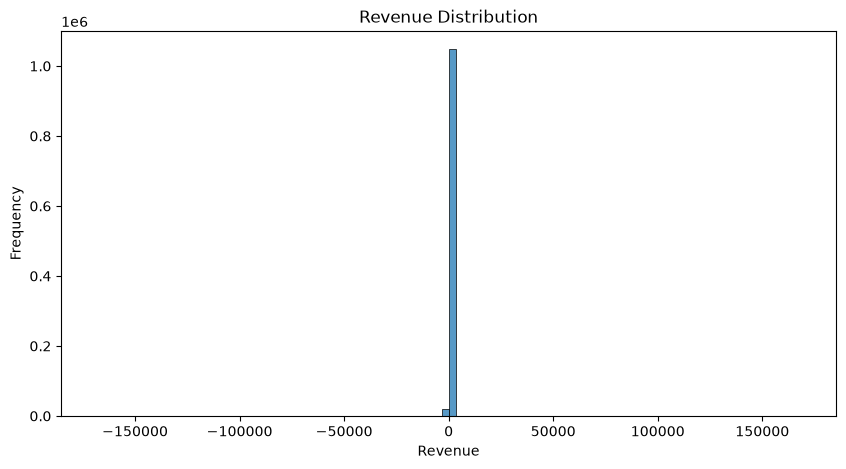

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Revenue"],
    bins=100
)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [21]:
profiling_report = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "total_missing_values": int(df.isnull().sum().sum()),
    "unique_customers": int(df["Customer ID"].nunique()),
    "unique_products": int(df["StockCode"].nunique()),
    "unique_invoices": int(df["Invoice"].nunique()),
    "unique_countries": int(df["Country"].nunique()),
    "total_revenue": float(df["Revenue"].sum())
}

profiling_report

{'rows': 1067371,
 'columns': 9,
 'duplicate_rows': 34335,
 'total_missing_values': 247389,
 'unique_customers': 5942,
 'unique_products': 5305,
 'unique_invoices': 53628,
 'unique_countries': 43,
 'total_revenue': 19287250.568}

In [22]:
import sys
sys.path.append("../")

In [23]:
from src.analysis.eda import calculate_sales_metrics,monthly_sales

In [24]:
from src.utils.cleaner import clean_data

In [25]:
cleaned_df=clean_data(df)

In [26]:
cleaned_df.shape

(1033036, 11)

In [27]:
sales_metrics = calculate_sales_metrics(cleaned_df)

sales_metrics

{'total_revenue': 18855533.698,
 'total_transactions': 53628,
 'total_products': 5305,
 'total_customers': 5942,
 'total_countries': 43,
 'average_order_value': 351.5986741627508}

In [28]:
cleaned_df.columns.tolist()

['invoice',
 'stock_code',
 'description',
 'quantity',
 'invoice_date',
 'price',
 'customer_id',
 'country',
 'Revenue',
 'is_cancelled',
 'revenue']

In [29]:
monthly=monthly_sales(cleaned_df)
monthly.head()

,year_month,revenue
0,2009-12-01,796648.500
1,2010-01-01,622479.502
2,2010-02-01,531265.366
3,2010-03-01,763247.241
4,2010-04-01,587926.692


In [30]:
monthly.shape

(25, 2)

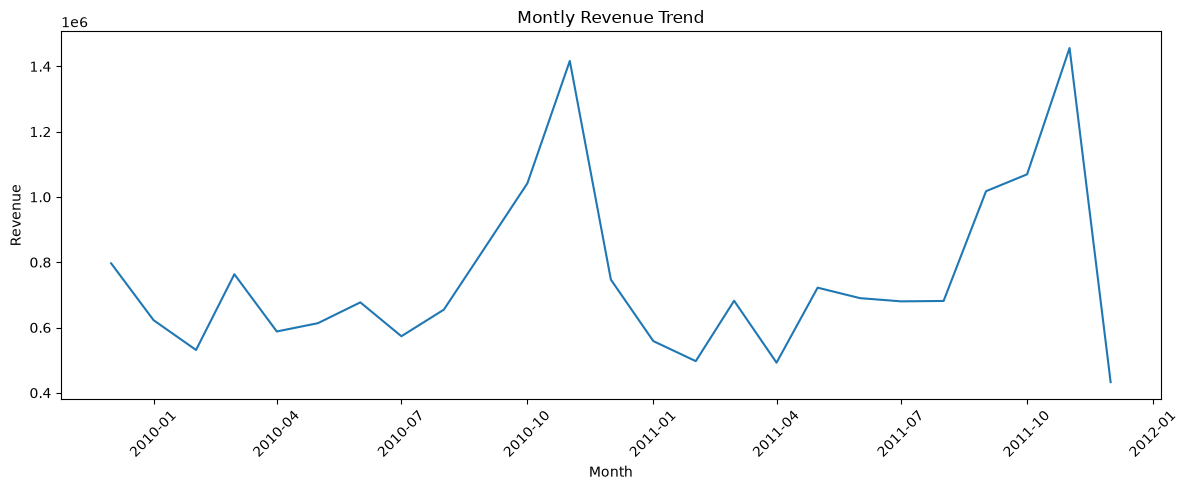

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly["year_month"],
    monthly["revenue"]
)

plt.title("Montly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
top_products=(
    cleaned_df
    .groupby("stock_code")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

stock_code
22423     314045.02
DOT       309844.10
85123A    248337.61
85099B    178400.52
47566     147079.73
84879     128550.42
22086     116298.59
POST      110430.41
79321      79905.13
22197      78903.62
Name: revenue, dtype: float64

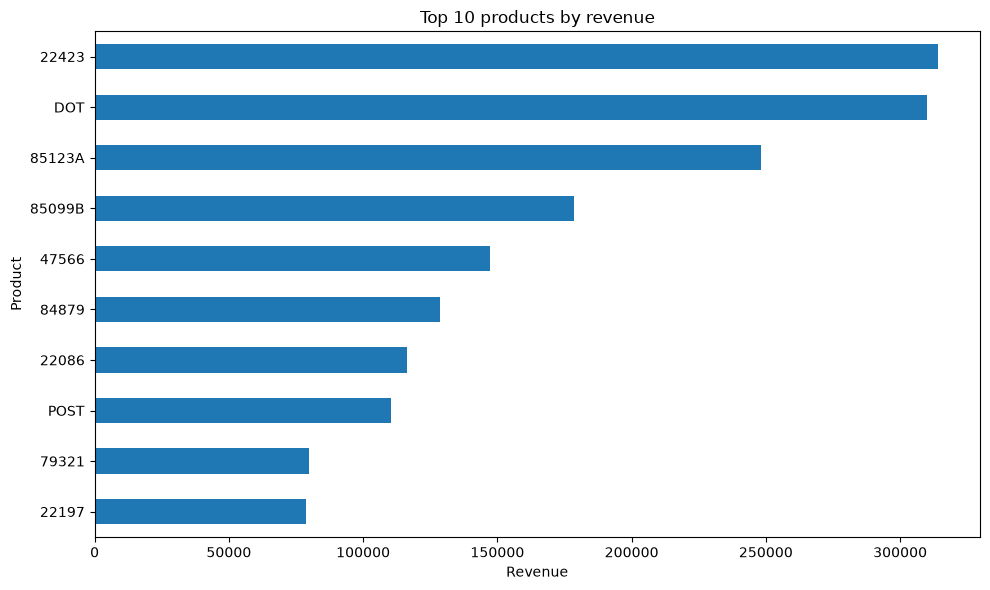

In [33]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 products by revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [34]:
top_countries=(
    cleaned_df
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_countries

country
United Kingdom    1.598606e+07
EIRE              6.099538e+05
Netherlands       5.483307e+05
Germany           4.119592e+05
France            3.217334e+05
Australia         1.664444e+05
Switzerland       9.940306e+04
Spain             9.101344e+04
Sweden            8.777552e+04
Denmark           6.445959e+04
Name: revenue, dtype: float64

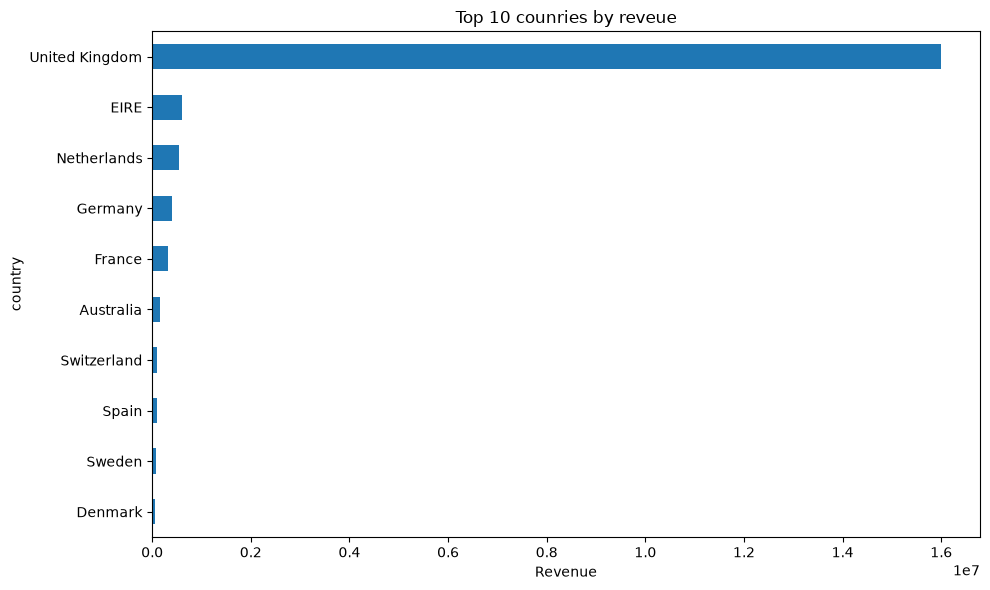

In [35]:
plt.figure(figsize=(10,6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 counries by reveue")
plt.xlabel("Revenue")
plt.ylabel("country")
plt.tight_layout()
plt.show()

In [36]:
customer_revenue=(
    cleaned_df
    .groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
customer_revenue.head(20)

customer_id
18102.0    570380.61
14646.0    523342.07
14156.0    296063.44
14911.0    265757.91
17450.0    231390.55
13694.0    190020.84
17511.0    168491.62
12415.0    143269.29
16684.0    141502.25
15061.0    124961.98
15311.0    111739.36
13089.0    109893.24
17949.0     97581.59
14298.0     90489.31
16029.0     89705.47
15769.0     84177.58
13798.0     73166.92
15838.0     72727.41
12931.0     71299.67
17841.0     67186.87
Name: revenue, dtype: float64

In [37]:
from src.analysis.eda import(
    calculate_sales_metrics,
    monthly_sales,
    top_products,
    top_countries,
    customer_revenue
)

In [38]:
import sys

print(sys.executable)

c:\Project\Data Science\Autonomous Data Analyst\.venv\Scripts\python.exe


In [39]:
import importlib
import src.analysis.eda as eda

importlib.reload(eda)

print(eda.__file__)
print([x for x in dir(eda) if not x.startswith("_")])

c:\Project\Data Science\Autonomous Data Analyst\src\analysis\eda.py
['calculate_sales_metrics', 'customer_revenue', 'monthly_sales', 'pd', 'top_countries', 'top_products']


In [40]:
import sys 
import os 
sys.path.insert(0,os.path.abspath(".."))
print(os.getcwd())
print(sys.path[0])

c:\Project\Data Science\Autonomous Data Analyst\notebooks
c:\Project\Data Science\Autonomous Data Analyst


In [41]:
import src.analysis.eda as eda
print(eda.__file__)
print([x for x in dir(eda) if not x.startswith("_")])

c:\Project\Data Science\Autonomous Data Analyst\src\analysis\eda.py
['calculate_sales_metrics', 'customer_revenue', 'monthly_sales', 'pd', 'top_countries', 'top_products']


In [42]:
products=top_products(cleaned_df)
products.head(10)

AttributeError: 'Series' object has no attribute 'sort_value'

In [ ]:
countries=top_countries(cleaned_df)
countries.head(10)

,country,revenue
0,United Kingdom,1.598606e+07
1,EIRE,6.099538e+05
2,Netherlands,5.483307e+05
3,Germany,4.119592e+05
4,France,3.217334e+05
5,Australia,1.664444e+05
6,Switzerland,9.940306e+04
7,Spain,9.101344e+04
8,Sweden,8.777552e+04
9,Denmark,6.445959e+04


In [ ]:
customers=customer_revenue(cleaned_df)
customers.head(10)

,customer_id,revenue
0,18102.0,570380.61
1,14646.0,523342.07
2,14156.0,296063.44
3,14911.0,265757.91
4,17450.0,231390.55
5,13694.0,190020.84
6,17511.0,168491.62
7,12415.0,143269.29
8,16684.0,141502.25
9,15061.0,124961.98


In [ ]:
def generate_eda_summary(df:pd.DataFrame)->dict:
    """Generate a complete high-level EDA summary."""

    return {
        "sales_metrics":calculate_sales_metrics(df),
        "monthly_sales":monthly_sales(df),
        "top_prodcuts": top_products(df),
        "top_countries":top_countries(df),
        "customer_revenue":customer_revenue(df)
    }

In [ ]:
from src.analysis.eda import generate_eda_summary

ImportError: cannot import name 'generate_eda_summary' from 'src.analysis.eda' (c:\Project\Data Science\Autonomous Data Analyst\notebooks\..\src\analysis\eda.py)

In [ ]:
eda_summary=generate_eda_summary(cleaned_df)

In [ ]:
eda_summary.keys()

In [ ]:
from src.analysis.customer import calculate_rfm

In [ ]:
rfm=calculate_rfm(cleaned_df)
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [ ]:
rfm.shape

(5878, 4)

In [ ]:
rfm.describe()

,customer_id,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


In [ ]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  5878 non-null   float64
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 183.8 KB


In [ ]:
rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

,customer_id,Recency,Frequency,Monetary
5692,18102.0,1,145,580987.04
2277,14646.0,2,151,528602.52
1789,14156.0,10,156,313437.62
2538,14911.0,1,398,291420.81
5050,17450.0,8,51,244784.25
1331,13694.0,4,143,195640.69
5109,17511.0,3,60,172132.87
4061,16446.0,1,2,168472.50
4295,16684.0,4,55,147142.77
68,12415.0,24,28,144458.37


In [ ]:
rfm.sort_values(
    "Frequency",
    ascending=False
).head(10)

,customer_id,Recency,Frequency,Monetary
2538,14911.0,1,398,291420.81
400,12748.0,1,336,53539.64
5433,17841.0,2,211,68545.25
2935,15311.0,1,208,114966.42
739,13089.0,3,203,113416.91
2237,14606.0,1,192,29951.37
1789,14156.0,10,156,313437.62
5442,17850.0,372,155,51208.87
2277,14646.0,2,151,528602.52
5692,18102.0,1,145,580987.04


In [ ]:
rfm.sort_values(
    "Recency",
    ascending=True
).head(10)

,customer_id,Recency,Frequency,Monetary
5178,17581.0,1,43,17951.17
4846,17243.0,1,69,20203.58
76,12423.0,1,10,2622.39
1161,13521.0,1,3,1071.73
1413,13777.0,1,61,49638.26
762,13113.0,1,37,18230.07
748,13098.0,1,28,28882.44
2361,14730.0,1,8,1897.57
1686,14051.0,1,37,21770.98
751,13102.0,1,37,11380.10


In [ ]:
rfm["R_score"]=pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1],
    duplicates="drop"
)
rfm["F_score"]=pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)
rfm["M_score"]=pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm["RFM_Score"]=(
    rfm["R_score"].astype(int)
    +rfm["F_score"].astype(int)
    +rfm["M_score"].astype(int)
)

In [ ]:
rfm.head(10)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,12
1,12347.0,2,8,4921.53,5,4,5,14
2,12348.0,75,5,2019.40,3,4,4,11
3,12349.0,19,4,4428.69,5,3,5,13
4,12350.0,310,1,334.40,2,1,2,5
5,12351.0,375,1,300.93,2,1,2,5
6,12352.0,36,10,2849.84,4,5,4,13
7,12353.0,204,2,406.76,2,2,2,6
8,12354.0,232,1,1079.40,2,1,3,6
9,12355.0,214,2,947.61,2,2,3,7


In [ ]:
def segment_customer(row):
    score=row["RFM_Score"]
    if score>=13:
        return "Champions"
    elif score>=10:
        return "Loyal Customers"
    elif score>=7:
        return "Potential Loyalists"
    elif score>=5:
        return "At Risk"
    else:
        return "Lost Customers"

In [ ]:
rfm["Segment"]=rfm.apply(segment_customer,axis=1)
rfm["Segment"].value_counts()

Segment
Potential Loyalists    1453
Loyal Customers        1357
Champions              1295
At Risk                 967
Lost Customers          806
Name: count, dtype: int64

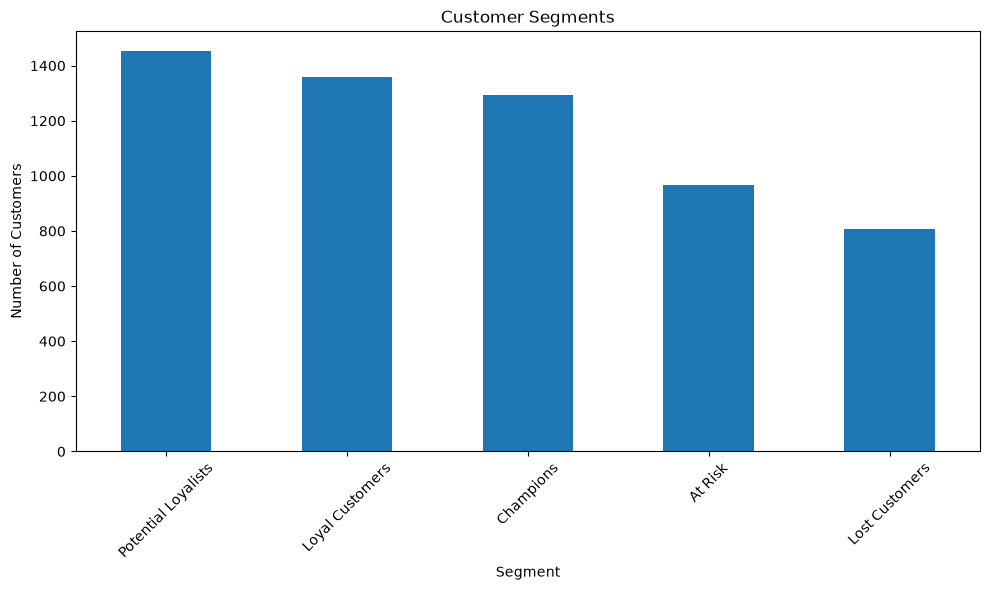

In [ ]:
import matplotlib.pyplot as plt

segment_counts=rfm["Segment"].value_counts()
plt.figure(figsize=(10,6))
segment_counts.plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .round(2)
    .sort_values("avg_monetary", ascending=False)
)

segment_summary

KeyError: 'segment'

In [ ]:
rfm.columns.tolist() 
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,12,Loyal Customers
1,12347.0,2,8,4921.53,5,4,5,14,Champions
2,12348.0,75,5,2019.40,3,4,4,11,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,13,Champions
4,12350.0,310,1,334.40,2,1,2,5,At Risk


In [ ]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,12,Loyal Customers
1,12347.0,2,8,4921.53,5,4,5,14,Champions
2,12348.0,75,5,2019.40,3,4,4,11,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,13,Champions
4,12350.0,310,1,334.40,2,1,2,5,At Risk


In [ ]:
def assign_segment(score):
    if score>=11:
        return "Champions"
    elif score>=9:
        return "Loyal Customer"
    elif score>=7:
        return "Potential Loyalists"
    elif score>=5:
        return "At Risk"
    else:
        return "Low Value"
rfm["segment"]=rfm["rfm_score"].apply(assign_segment)

KeyError: 'rfm_score'

In [ ]:
rfm[["customer_id","rfm_score","segment"]].head()

KeyError: "['rfm_score', 'segment'] not in index"

In [ ]:
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

rfm["rfm_score"] = (
    rfm["R_score"]
    + rfm["F_score"]
    + rfm["M_score"]
)

rfm[[
    "customer_id",
    "R_score",
    "F_score",
    "M_score",
    "rfm_score"
]].head()

,customer_id,R_score,F_score,M_score,rfm_score
0,12346.0,2,5,5,12
1,12347.0,5,4,5,14
2,12348.0,3,4,4,11
3,12349.0,5,3,5,13
4,12350.0,2,1,2,5


In [ ]:
def assign_segment(score):
    if score >= 12:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 8:
        return "Potential Loyalists"
    elif score >= 6:
        return "At Risk"
    else:
        return "Low Value"


rfm["segment"] = rfm["rfm_score"].apply(assign_segment)

rfm[[
    "customer_id",
    "rfm_score",
    "segment"
]].head(10)

,customer_id,rfm_score,segment
0,12346.0,12,Champions
1,12347.0,14,Champions
2,12348.0,11,Loyal Customers
3,12349.0,13,Champions
4,12350.0,5,Low Value
5,12351.0,5,Low Value
6,12352.0,13,Champions
7,12353.0,6,At Risk
8,12354.0,6,At Risk
9,12355.0,7,At Risk


In [ ]:
rfm["segment"].value_counts()

segment
Champions              1724
Low Value              1308
Potential Loyalists     980
At Risk                 938
Loyal Customers         928
Name: count, dtype: int64

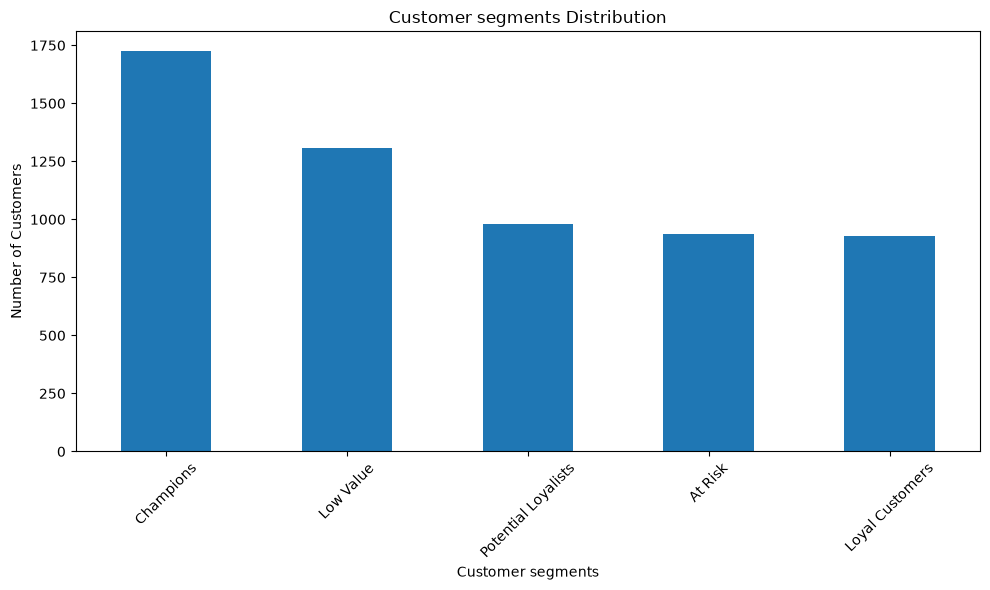

In [ ]:
import matplotlib.pyplot as plt 
segment_counts=rfm["segment"].value_counts() 
plt.figure(figsize=(10,6))
segment_counts.plot(kind="bar")
plt.title("Customer segments Distribution")
plt.xlabel("Customer segments")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean")
    )
    .round(2)
    .sort_values("avg_monetary", ascending=False)
)

segment_summary

,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Champions,1724,35.28,15.30,8122.37
Loyal Customers,928,110.50,4.78,1725.46
Potential Loyalists,980,180.83,3.01,947.70
At Risk,938,258.88,1.82,554.62
Low Value,1308,458.73,1.14,245.91


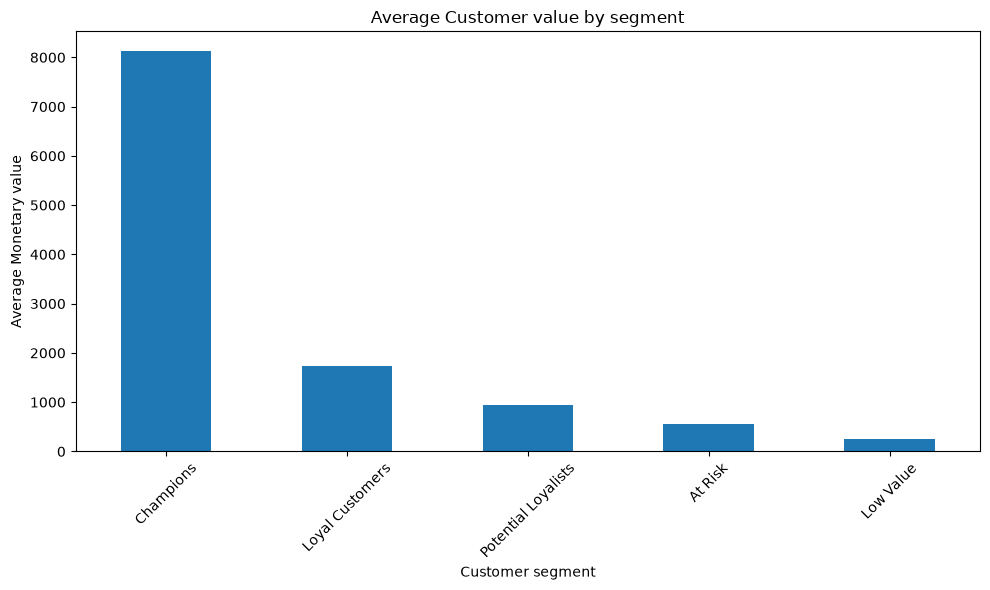

In [ ]:
segment_summary["avg_monetary"].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Average Customer value by segment")
plt.xlabel("Customer segment")
plt.ylabel("Average Monetary value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
segment_insights=[]
for segment,row in segment_summary.iterrows():
    insight=(
        f"{segment}:{int(row['customers'])}customers,"
        f"average recency {row['avg_recency']:.0f}days,"
        f"average frequency {row['avg_frequency']:.2f},"
        f"average monetary value {row['avg_monetary']:.2f}."
    )
    segment_insights.append(insight)

for insight in segment_insights:
    print(insight)

Champions:1724customers,average recency 35days,average frequency 15.30,average monetary value 8122.37.
Loyal Customers:928customers,average recency 110days,average frequency 4.78,average monetary value 1725.46.
Potential Loyalists:980customers,average recency 181days,average frequency 3.01,average monetary value 947.70.
At Risk:938customers,average recency 259days,average frequency 1.82,average monetary value 554.62.
Low Value:1308customers,average recency 459days,average frequency 1.14,average monetary value 245.91.


CUSTOMER SEGMENT SUMMARY


,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Champions,1724,35.28,15.30,8122.37
Loyal Customers,928,110.50,4.78,1725.46
Potential Loyalists,980,180.83,3.01,947.70
At Risk,938,258.88,1.82,554.62
Low Value,1308,458.73,1.14,245.91



BUSINESS INSIGHTS

Champions
  Customers: 1724
  Average Recency: 35 days
  Average Frequency: 15.30
  Average Monetary Value: 8122.37

Loyal Customers
  Customers: 928
  Average Recency: 110 days
  Average Frequency: 4.78
  Average Monetary Value: 1725.46

Potential Loyalists
  Customers: 980
  Average Recency: 181 days
  Average Frequency: 3.01
  Average Monetary Value: 947.70

At Risk
  Customers: 938
  Average Recency: 259 days
  Average Frequency: 1.82
  Average Monetary Value: 554.62

Low Value
  Customers: 1308
  Average Recency: 459 days
  Average Frequency: 1.14
  Average Monetary Value: 245.91


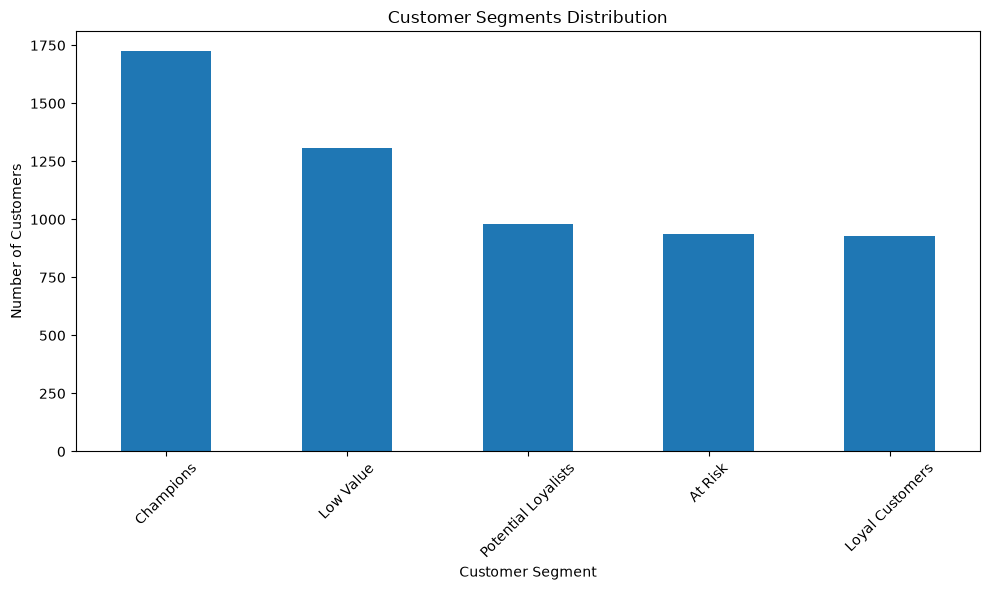

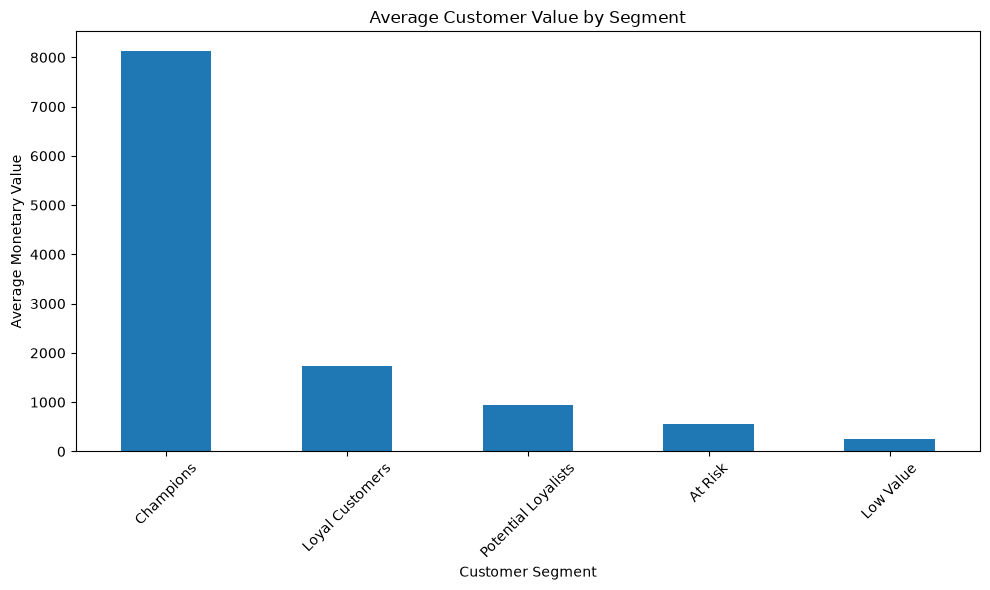


Customer segmentation analysis completed successfully.
Files saved:
1. data/processed/customer_rfm_segments.csv
2. data/processed/customer_segment_summary.csv


In [ ]:
# ============================================================
# CUSTOMER SEGMENTATION - FINAL ANALYSIS & EXPORT
# ============================================================

import os
import matplotlib.pyplot as plt

# 1. Display segment summary
print("CUSTOMER SEGMENT SUMMARY")
print("=" * 60)

display(segment_summary)


# 2. Generate business insights
print("\nBUSINESS INSIGHTS")
print("=" * 60)

for segment, row in segment_summary.iterrows():
    print(
        f"\n{segment}"
        f"\n  Customers: {int(row['customers'])}"
        f"\n  Average Recency: {row['avg_recency']:.0f} days"
        f"\n  Average Frequency: {row['avg_frequency']:.2f}"
        f"\n  Average Monetary Value: {row['avg_monetary']:.2f}"
    )


# 3. Customer count by segment
plt.figure(figsize=(10, 6))

rfm["segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 4. Average monetary value by segment
plt.figure(figsize=(10, 6))

segment_summary["avg_monetary"].plot(kind="bar")

plt.title("Average Customer Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Create processed-data folder
os.makedirs("../data/processed", exist_ok=True)


# 6. Save customer-level RFM segmentation
rfm.to_csv(
    "../data/processed/customer_rfm_segments.csv",
    index=False
)


# 7. Save segment-level summary
segment_summary.to_csv(
    "../data/processed/customer_segment_summary.csv"
)


print("\n" + "=" * 60)
print("Customer segmentation analysis completed successfully.")
print("Files saved:")
print("1. data/processed/customer_rfm_segments.csv")
print("2. data/processed/customer_segment_summary.csv")

In [ ]:
import os

os.makedirs("../data/processed", exist_ok=True)

rfm.to_csv(
    "../data/processed/customer_rfm_segments.csv",
    index=False
)

segment_summary.to_csv(
    "../data/processed/customer_segment_summary.csv",
    index=False
)

print("Customer segmentation results saved successfully.")

Customer segmentation results saved successfully.


In [ ]:
# Verify saved customer segmentation files

rfm_check = pd.read_csv(
    "../data/processed/customer_rfm_segments.csv"
)

segment_check = pd.read_csv(
    "../data/processed/customer_segment_summary.csv"
)

print("RFM file shape:", rfm_check.shape)
print("Segment summary shape:", segment_check.shape)

print("\nRFM columns:")
print(rfm_check.columns.tolist())

print("\nSegment summary:")
display(segment_check)

RFM file shape: (5878, 11)
Segment summary shape: (5, 4)

RFM columns:
['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'Segment', 'rfm_score', 'segment']

Segment summary:


,customers,avg_recency,avg_frequency,avg_monetary
0,1724,35.28,15.30,8122.37
1,928,110.50,4.78,1725.46
2,980,180.83,3.01,947.70
3,938,258.88,1.82,554.62
4,1308,458.73,1.14,245.91


In [ ]:
# ============================================================
# 5.17 - SEGMENT-LEVEL REVENUE ANALYSIS
# ============================================================

# Calculate total revenue generated by each customer segment
segment_revenue = (
    rfm.groupby("segment")
    .agg(
        total_revenue=("Monetary", "sum"),
        customers=("customer_id", "count")
    )
    .sort_values("total_revenue", ascending=False)
)

# Calculate revenue percentage contribution
segment_revenue["revenue_percentage"] = (
    segment_revenue["total_revenue"]
    / segment_revenue["total_revenue"].sum()
    * 100
).round(2)

# Round revenue values
segment_revenue["total_revenue"] = (
    segment_revenue["total_revenue"]
    .round(2)
)

# Display result
segment_revenue

,total_revenue,customers,revenue_percentage
segment,,,
Champions,14002958.34,1724,80.59
Loyal Customers,1601228.34,928,9.22
Potential Loyalists,928744.85,980,5.35
At Risk,520228.87,938,2.99
Low Value,321643.86,1308,1.85


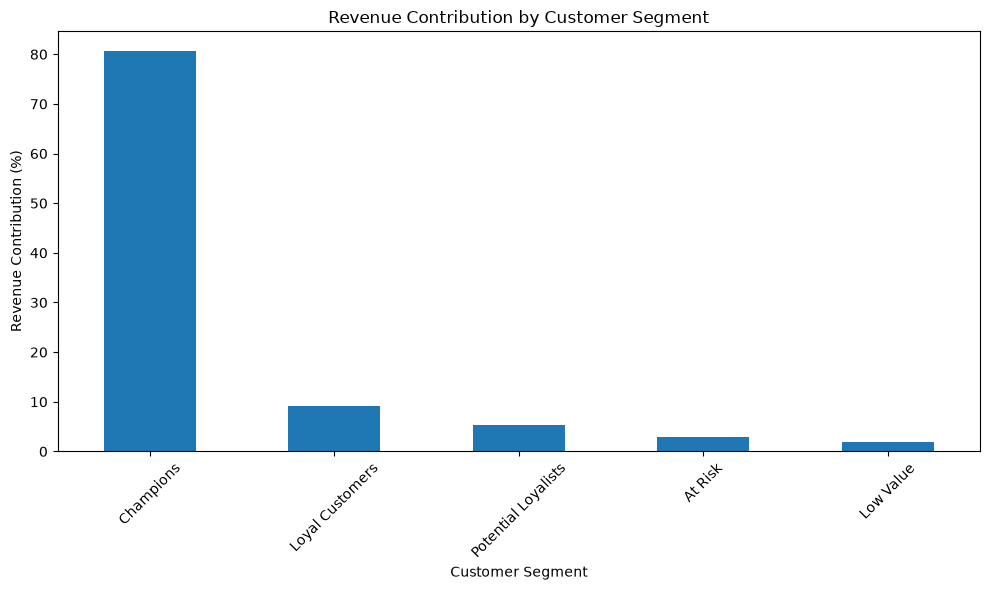

In [ ]:
# ============================================================
# 5.18 - REVENUE CONTRIBUTION BY CUSTOMER SEGMENT
# ============================================================

import matplotlib.pyplot as plt

segment_revenue["revenue_percentage"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 5.19 - HIGH-VALUE CUSTOMER ANALYSIS
# ============================================================

high_value_customers = (
    rfm[
        [
            "customer_id",
            "Recency",
            "Frequency",
            "Monetary",
            "RFM_score",
            "segment"
        ]
    ]
    .sort_values("Monetary", ascending=False)
    .head(20)
)

print("TOP 20 HIGH-VALUE CUSTOMERS")
print("=" * 60)

display(high_value_customers)

KeyError: "['RFM_score'] not in index"

In [ ]:
cleaned_df.columns.tolist()

['invoice',
 'stock_code',
 'description',
 'quantity',
 'invoice_date',
 'price',
 'customer_id',
 'country',
 'Revenue',
 'is_cancelled',
 'revenue']

In [ ]:
# 5.20 - HIGH-VALUE CUSTOMER SUMMARY

# Create the high-value customer table again
high_value_customers = (
    rfm[
        [
            "customer_id",
            "Recency",
            "Frequency",
            "Monetary",
            "R_score",
            "F_score",
            "M_score",
            "segment"
        ]
    ]
    .sort_values("Monetary", ascending=False)
    .head(20)
)

# Calculate summary metrics
high_value_summary = {
    "Total High-Value Customers": len(high_value_customers),
    "Total Revenue": high_value_customers["Monetary"].sum(),
    "Average Revenue per Customer": high_value_customers["Monetary"].mean(),
    "Highest Customer Revenue": high_value_customers["Monetary"].max(),
    "Average Frequency": high_value_customers["Frequency"].mean(),
    "Average Recency": high_value_customers["Recency"].mean()
}

# Display results
print("HIGH-VALUE CUSTOMER SUMMARY")
print("=" * 60)

for metric, value in high_value_summary.items():
    print(f"{metric}: {value:,.2f}")

HIGH-VALUE CUSTOMER SUMMARY
Total High-Value Customers: 20.00
Total Revenue: 3,802,069.17
Average Revenue per Customer: 190,103.46
Highest Customer Revenue: 580,987.04
Average Frequency: 112.95
Average Recency: 23.50


In [ ]:
# 5.21 - HIGH-VALUE CUSTOMERS BY SEGMENT

high_value_by_segment = (
    high_value_customers
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("Monetary", "sum"),
        average_revenue=("Monetary", "mean"),
        average_frequency=("Frequency", "mean"),
        average_recency=("Recency", "mean")
    )
    .round(2)
    .sort_values("total_revenue", ascending=False)
)

print("HIGH-VALUE CUSTOMERS BY SEGMENT")
print("=" * 60)

display(high_value_by_segment)

HIGH-VALUE CUSTOMERS BY SEGMENT


,customers,total_revenue,average_revenue,average_frequency,average_recency
segment,,,,,
Champions,20,3802069.17,190103.46,112.95,23.5


In [ ]:
# 5.22 - SEGMENT REVENUE CONTRIBUTION

segment_revenue = (
    rfm
    .groupby("segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="total_revenue")
)

# Calculate percentage contribution
total_revenue = segment_revenue["total_revenue"].sum()

segment_revenue["revenue_percentage"] = (
    segment_revenue["total_revenue"] / total_revenue * 100
).round(2)

print("SEGMENT REVENUE CONTRIBUTION")
print("=" * 60)

display(segment_revenue)

SEGMENT REVENUE CONTRIBUTION


,total_revenue,revenue_percentage
segment,,
Champions,1.400296e+07,80.59
Loyal Customers,1.601228e+06,9.22
Potential Loyalists,9.287449e+05,5.35
At Risk,5.202289e+05,2.99
Low Value,3.216439e+05,1.85


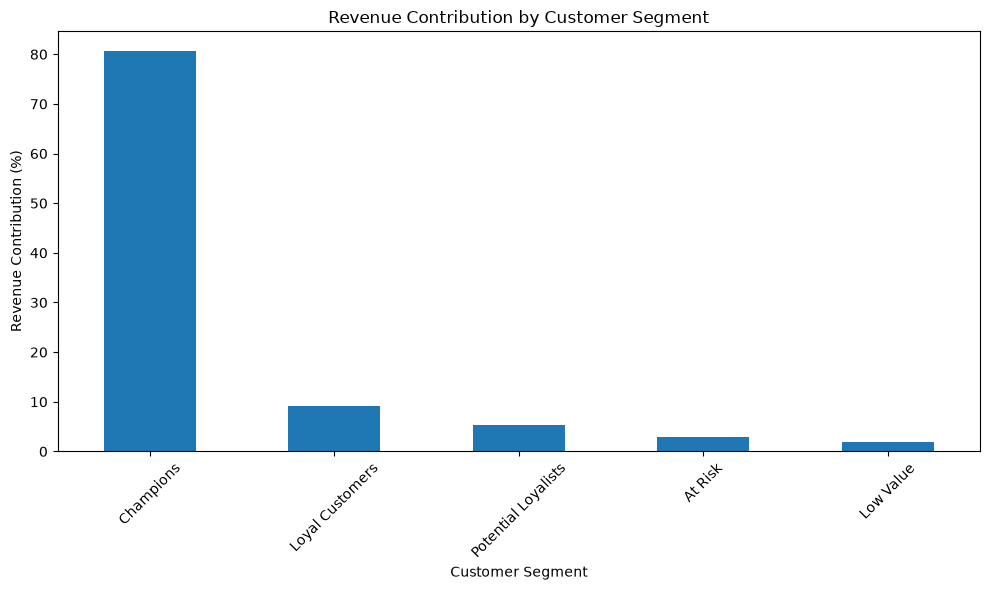

In [ ]:
# 5.23 - SEGMENT REVENUE CONTRIBUTION VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

segment_revenue["revenue_percentage"].plot(
    kind="bar"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 5.24 - CUSTOMER SEGMENT BUSINESS RECOMMENDATIONS

segment_recommendations = {
    "Champions": (
        "Reward and retain these customers with loyalty benefits, "
        "exclusive offers, and early access to new products."
    ),

    "Loyal Customers": (
        "Encourage repeat purchases through personalized offers, "
        "cross-selling, and loyalty programs."
    ),

    "Potential Loyalists": (
        "Increase engagement with targeted promotions, "
        "product recommendations, and loyalty incentives."
    ),

    "At Risk": (
        "Launch re-engagement campaigns, personalized discounts, "
        "and reminders to bring inactive customers back."
    ),

    "Low Value": (
        "Use low-cost marketing campaigns and targeted offers "
        "to increase purchase frequency and customer value."
    )
}

print("CUSTOMER SEGMENT BUSINESS RECOMMENDATIONS")
print("=" * 70)

for segment, recommendation in segment_recommendations.items():

    if segment in rfm["segment"].unique():
        print(f"\n{segment}")
        print("-" * len(segment))
        print(recommendation)

CUSTOMER SEGMENT BUSINESS RECOMMENDATIONS

Champions
---------
Reward and retain these customers with loyalty benefits, exclusive offers, and early access to new products.

Loyal Customers
---------------
Encourage repeat purchases through personalized offers, cross-selling, and loyalty programs.

Potential Loyalists
-------------------
Increase engagement with targeted promotions, product recommendations, and loyalty incentives.

At Risk
-------
Launch re-engagement campaigns, personalized discounts, and reminders to bring inactive customers back.

Low Value
---------
Use low-cost marketing campaigns and targeted offers to increase purchase frequency and customer value.


In [ ]:
# 5.25 - COMPLETE CUSTOMER SEGMENT INSIGHTS

segment_insights = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean")
    )
    .round(2)
)

# Add revenue contribution
segment_insights["total_revenue"] = (
    rfm.groupby("segment")["Monetary"]
    .sum()
)

segment_insights["revenue_percentage"] = (
    segment_insights["total_revenue"]
    / segment_insights["total_revenue"].sum()
    * 100
).round(2)

# Add business recommendation
segment_insights["recommendation"] = (
    segment_insights.index
    .map(segment_recommendations)
)

print("COMPLETE CUSTOMER SEGMENT INSIGHTS")
print("=" * 70)

display(segment_insights)

COMPLETE CUSTOMER SEGMENT INSIGHTS


,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_percentage,recommendation
segment,,,,,,,
At Risk,938,258.88,1.82,554.62,5.202289e+05,2.99,"Launch re-engagement campaigns, personalized d..."
Champions,1724,35.28,15.30,8122.37,1.400296e+07,80.59,Reward and retain these customers with loyalty...
Low Value,1308,458.73,1.14,245.91,3.216439e+05,1.85,Use low-cost marketing campaigns and targeted ...
Loyal Customers,928,110.50,4.78,1725.46,1.601228e+06,9.22,Encourage repeat purchases through personalize...
Potential Loyalists,980,180.83,3.01,947.70,9.287449e+05,5.35,"Increase engagement with targeted promotions, ..."


In [ ]:
# 5.26 - SEGMENT SIZE AND REVENUE ANALYSIS

segment_analysis = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("Monetary", "sum"),
        average_revenue=("Monetary", "mean")
    )
    .round(2)
)

# Calculate percentage of customers
total_customers = segment_analysis["customers"].sum()

segment_analysis["customer_percentage"] = (
    segment_analysis["customers"] / total_customers * 100
).round(2)

# Calculate percentage of revenue
total_segment_revenue = segment_analysis["total_revenue"].sum()

segment_analysis["revenue_percentage"] = (
    segment_analysis["total_revenue"] / total_segment_revenue * 100
).round(2)

print("SEGMENT SIZE AND REVENUE ANALYSIS")
print("=" * 70)

display(
    segment_analysis.sort_values(
        "total_revenue",
        ascending=False
    )
)

SEGMENT SIZE AND REVENUE ANALYSIS


,customers,total_revenue,average_revenue,customer_percentage,revenue_percentage
segment,,,,,
Champions,1724,14002958.34,8122.37,29.33,80.59
Loyal Customers,928,1601228.34,1725.46,15.79,9.22
Potential Loyalists,980,928744.85,947.70,16.67,5.35
At Risk,938,520228.87,554.62,15.96,2.99
Low Value,1308,321643.86,245.91,22.25,1.85


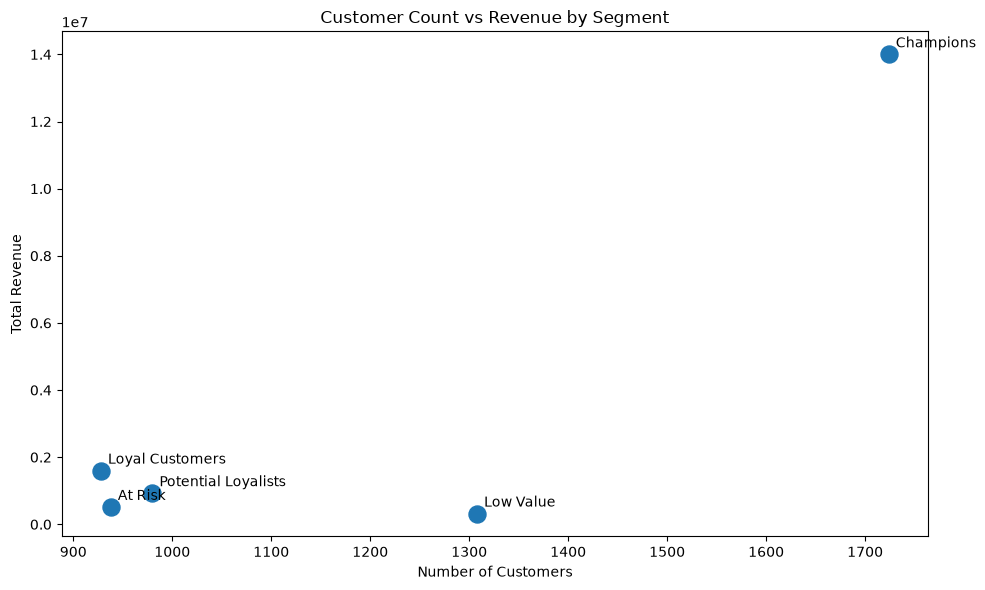

In [ ]:
# 5.27 - CUSTOMER COUNT VS REVENUE VISUALIZATION

import matplotlib.pyplot as plt

plot_data = segment_analysis.sort_values(
    "total_revenue",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["customers"],
    plot_data["total_revenue"],
    s=150
)

for segment in plot_data.index:
    plt.annotate(
        segment,
        (
            plot_data.loc[segment, "customers"],
            plot_data.loc[segment, "total_revenue"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Customer Count vs Revenue by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [ ]:
# 5.28 - FINAL CUSTOMER SEGMENTATION INSIGHTS

print("FINAL CUSTOMER SEGMENTATION INSIGHTS")
print("=" * 70)

# Largest segment by customer count
largest_segment = segment_analysis["customers"].idxmax()

# Highest revenue segment
highest_revenue_segment = segment_analysis["total_revenue"].idxmax()

# Highest average customer value
highest_value_segment = segment_analysis["average_revenue"].idxmax()

print(
    f"\nLargest customer segment: {largest_segment}"
)

print(
    f"Customers in largest segment: "
    f"{segment_analysis.loc[largest_segment, 'customers']:,}"
)

print(
    f"\nHighest revenue segment: {highest_revenue_segment}"
)

print(
    f"Revenue from highest revenue segment: "
    f"{segment_analysis.loc[highest_revenue_segment, 'total_revenue']:,.2f}"
)

print(
    f"\nHighest average customer value segment: "
    f"{highest_value_segment}"
)

print(
    f"Average revenue per customer: "
    f"{segment_analysis.loc[highest_value_segment, 'average_revenue']:,.2f}"
)

print("\nSEGMENT OVERVIEW")
print("-" * 70)

display(
    segment_analysis.sort_values(
        "total_revenue",
        ascending=False
    )
)

FINAL CUSTOMER SEGMENTATION INSIGHTS

Largest customer segment: Champions
Customers in largest segment: 1,724

Highest revenue segment: Champions
Revenue from highest revenue segment: 14,002,958.34

Highest average customer value segment: Champions
Average revenue per customer: 8,122.37

SEGMENT OVERVIEW
----------------------------------------------------------------------


,customers,total_revenue,average_revenue,customer_percentage,revenue_percentage
segment,,,,,
Champions,1724,14002958.34,8122.37,29.33,80.59
Loyal Customers,928,1601228.34,1725.46,15.79,9.22
Potential Loyalists,980,928744.85,947.70,16.67,5.35
At Risk,938,520228.87,554.62,15.96,2.99
Low Value,1308,321643.86,245.91,22.25,1.85


In [ ]:
# 6.1 - PREPARE CUSTOMER ML DATASET

import pandas as pd
import numpy as np

print("Starting ML dataset preparation...")

# Copy cleaned transaction data
ml_source = cleaned_df.copy()

# Make sure required columns exist
required_columns = [
    "customer_id",
    "invoice_date",
    "invoice",
    "revenue"
]

missing_columns = [
    col for col in required_columns
    if col not in ml_source.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Remove invalid records
ml_source = ml_source.dropna(
    subset=["customer_id", "invoice_date", "revenue"]
)

# Remove cancelled/invalid transactions
if "is_cancelled" in ml_source.columns:
    ml_source = ml_source[
        ml_source["is_cancelled"] == False
    ]

ml_source = ml_source[
    ml_source["revenue"] > 0
]

# Convert date
ml_source["invoice_date"] = pd.to_datetime(
    ml_source["invoice_date"]
)

# Sort chronologically
ml_source = ml_source.sort_values("invoice_date")

print("Transactions available for ML:", len(ml_source))
print("Customers available:", ml_source["customer_id"].nunique())
print(
    "Date range:",
    ml_source["invoice_date"].min(),
    "to",
    ml_source["invoice_date"].max()
)

Starting ML dataset preparation...
Transactions available for ML: 779425
Customers available: 5878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [ ]:
# 6.2 - CREATE TEMPORAL ML DATASET

# Find latest transaction date
max_date = ml_source["invoice_date"].max()

# Use final 90 days as prediction period
prediction_start = max_date - pd.Timedelta(days=90)

print("Historical period ends:", prediction_start)
print("Prediction period:", prediction_start, "to", max_date)

# Historical transactions
historical_data = ml_source[
    ml_source["invoice_date"] < prediction_start
].copy()

# Future transactions
future_data = ml_source[
    ml_source["invoice_date"] >= prediction_start
].copy()

print("\nHistorical transactions:", len(historical_data))
print("Future transactions:", len(future_data))

print(
    "\nHistorical customers:",
    historical_data["customer_id"].nunique()
)

print(
    "Future customers:",
    future_data["customer_id"].nunique()
)

Historical period ends: 2011-09-10 12:50:00
Prediction period: 2011-09-10 12:50:00 to 2011-12-09 12:50:00

Historical transactions: 620572
Future transactions: 158853

Historical customers: 5281
Future customers: 2889


In [ ]:
# 6.2 - CREATE TEMPORAL ML DATASET

# Find latest transaction date
max_date = ml_source["invoice_date"].max()

# Use final 90 days as prediction period
prediction_start = max_date - pd.Timedelta(days=90)

print("Historical period ends:", prediction_start)
print("Prediction period:", prediction_start, "to", max_date)

# Historical transactions
historical_data = ml_source[
    ml_source["invoice_date"] < prediction_start
].copy()

# Future transactions
future_data = ml_source[
    ml_source["invoice_date"] >= prediction_start
].copy()

print("\nHistorical transactions:", len(historical_data))
print("Future transactions:", len(future_data))

print(
    "\nHistorical customers:",
    historical_data["customer_id"].nunique()
)

print(
    "Future customers:",
    future_data["customer_id"].nunique()
)

Historical period ends: 2011-09-10 12:50:00
Prediction period: 2011-09-10 12:50:00 to 2011-12-09 12:50:00

Historical transactions: 620572
Future transactions: 158853

Historical customers: 5281
Future customers: 2889


In [ ]:
# 6.3 - BUILD CUSTOMER FEATURES

reference_date = historical_data["invoice_date"].max()

customer_features = (
    historical_data
    .groupby("customer_id")
    .agg(
        recency=(
            "invoice_date",
            lambda x: (reference_date - x.max()).days
        ),
        frequency=(
            "invoice",
            "nunique"
        ),
        historical_revenue=(
            "revenue",
            "sum"
        ),
        average_order_value=(
            "revenue",
            "mean"
        )
    )
    .reset_index()
)

# Add number of transactions
transaction_counts = (
    historical_data
    .groupby("customer_id")
    .size()
    .reset_index(name="transaction_count")
)

customer_features = customer_features.merge(
    transaction_counts,
    on="customer_id",
    how="left"
)

# Add quantity-based feature if available
if "quantity" in historical_data.columns:

    quantity_features = (
        historical_data
        .groupby("customer_id")["quantity"]
        .sum()
        .reset_index(name="total_quantity")
    )

    customer_features = customer_features.merge(
        quantity_features,
        on="customer_id",
        how="left"
    )

# Add product diversity if StockCode exists
if "stock_code" in historical_data.columns:

    product_features = (
        historical_data
        .groupby("customer_id")["stock_code"]
        .nunique()
        .reset_index(name="unique_products")
    )

    customer_features = customer_features.merge(
        product_features,
        on="customer_id",
        how="left"
    )

print("Customer feature dataset shape:")
print(customer_features.shape)

display(customer_features.head())

Customer feature dataset shape:
(5281, 8)


,customer_id,recency,frequency,historical_revenue,average_order_value,transaction_count,total_quantity,unique_products
0,12346.0,234,12,77556.46,2281.072353,34,74285,27
1,12347.0,38,6,3402.39,20.746280,164,2099,107
2,12348.0,157,4,1709.40,35.612500,48,2497,25
3,12349.0,316,3,2671.14,26.187647,102,993,90
4,12350.0,218,1,334.40,19.670588,17,197,17


In [ ]:
# 6.3 - BUILD CUSTOMER FEATURES

reference_date = historical_data["invoice_date"].max()

customer_features = (
    historical_data
    .groupby("customer_id")
    .agg(
        recency=(
            "invoice_date",
            lambda x: (reference_date - x.max()).days
        ),
        frequency=(
            "invoice",
            "nunique"
        ),
        historical_revenue=(
            "revenue",
            "sum"
        ),
        average_order_value=(
            "revenue",
            "mean"
        )
    )
    .reset_index()
)

# Add number of transactions
transaction_counts = (
    historical_data
    .groupby("customer_id")
    .size()
    .reset_index(name="transaction_count")
)

customer_features = customer_features.merge(
    transaction_counts,
    on="customer_id",
    how="left"
)

# Add quantity-based feature if available
if "quantity" in historical_data.columns:

    quantity_features = (
        historical_data
        .groupby("customer_id")["quantity"]
        .sum()
        .reset_index(name="total_quantity")
    )

    customer_features = customer_features.merge(
        quantity_features,
        on="customer_id",
        how="left"
    )

# Add product diversity if StockCode exists
if "stock_code" in historical_data.columns:

    product_features = (
        historical_data
        .groupby("customer_id")["stock_code"]
        .nunique()
        .reset_index(name="unique_products")
    )

    customer_features = customer_features.merge(
        product_features,
        on="customer_id",
        how="left"
    )

print("Customer feature dataset shape:")
print(customer_features.shape)

display(customer_features.head())

Customer feature dataset shape:
(5281, 8)


,customer_id,recency,frequency,historical_revenue,average_order_value,transaction_count,total_quantity,unique_products
0,12346.0,234,12,77556.46,2281.072353,34,74285,27
1,12347.0,38,6,3402.39,20.746280,164,2099,107
2,12348.0,157,4,1709.40,35.612500,48,2497,25
3,12349.0,316,3,2671.14,26.187647,102,993,90
4,12350.0,218,1,334.40,19.670588,17,197,17


In [ ]:
# 6.4 - CREATE FUTURE REVENUE TARGET

future_revenue = (
    future_data
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index(name="future_revenue")
)

ml_dataset = customer_features.merge(
    future_revenue,
    on="customer_id",
    how="left"
)

ml_dataset["future_revenue"] = (
    ml_dataset["future_revenue"]
    .fillna(0)
)

print("Final ML dataset shape:")
print(ml_dataset.shape)

print("\nColumns:")
print(ml_dataset.columns.tolist())

display(ml_dataset.head())

Final ML dataset shape:
(5281, 9)

Columns:
['customer_id', 'recency', 'frequency', 'historical_revenue', 'average_order_value', 'transaction_count', 'total_quantity', 'unique_products', 'future_revenue']


,customer_id,recency,frequency,historical_revenue,average_order_value,transaction_count,total_quantity,unique_products,future_revenue
0,12346.0,234,12,77556.46,2281.072353,34,74285,27,0.00
1,12347.0,38,6,3402.39,20.746280,164,2099,107,1519.14
2,12348.0,157,4,1709.40,35.612500,48,2497,25,310.00
3,12349.0,316,3,2671.14,26.187647,102,993,90,1757.55
4,12350.0,218,1,334.40,19.670588,17,197,17,0.00


In [ ]:
# 6.5 - PREPARE FEATURES AND TARGET

y = ml_dataset["future_revenue"]

X = ml_dataset.drop(
    columns=[
        "customer_id",
        "future_revenue"
    ]
)

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

print("Features:")
print(X.columns.tolist())

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features:
['recency', 'frequency', 'historical_revenue', 'average_order_value', 'transaction_count', 'total_quantity', 'unique_products']

Feature matrix shape: (5281, 7)
Target shape: (5281,)


,recency,frequency,historical_revenue,average_order_value,transaction_count,total_quantity,unique_products
0,234,12,77556.46,2281.072353,34,74285,27
1,38,6,3402.39,20.746280,164,2099,107
2,157,4,1709.40,35.612500,48,2497,25
3,316,3,2671.14,26.187647,102,993,90
4,218,1,334.40,19.670588,17,197,17


In [ ]:
# 6.7 - TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTrainingpy -m pip install scikit-learn target average:", y_train.mean())
print("Testing target average:", y_test.mean())

Training samples: 4224
Testing samples: 1057

Trainingpy -m pip install scikit-learn target average: 547.2259924242425
Testing target average: 690.5158278145695


In [ ]:
# 6.8 - TRAIN MACHINE LEARNING MODELS

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

print("\nAll models trained successfully.")

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully.


In [ ]:
# 6.9 - MODEL EVALUATION

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    "RMSE"
)

print("MODEL PERFORMANCE")
print("=" * 70)

display(model_results.round(2))

In [ ]:
# 6.9 - MODEL EVALUATION

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    "RMSE"
)

print("MODEL PERFORMANCE")
print("=" * 70)

display(model_results.round(2))

MODEL PERFORMANCE


,Model,MAE,RMSE,R2
1,Random Forest,592.07,5599.78,0.04
2,Gradient Boosting,588.13,5618.41,0.04
0,Linear Regression,603.39,5623.01,0.03


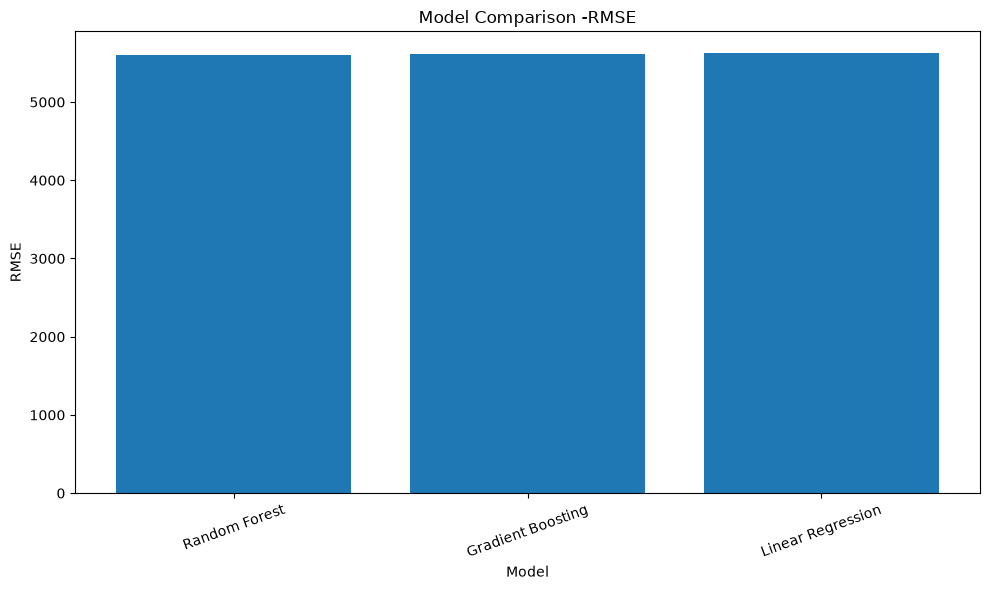

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6)) 
plt.bar(
    model_results["Model"],
    model_results["RMSE"]
) 
plt.title("Model Comparison -RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

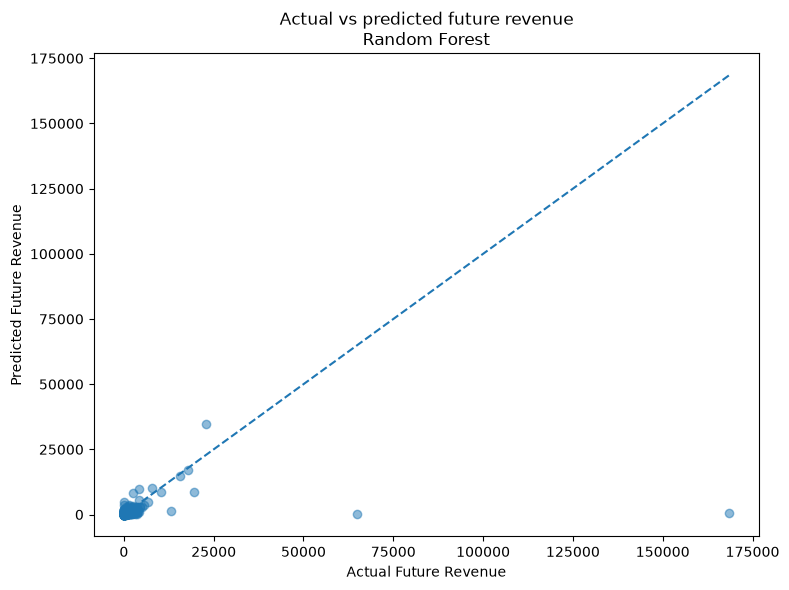

selected model: Random Forest


In [ ]:
best_model_name=model_results.iloc[0]["Model"]
best_model=trained_models[best_model_name] 
predictions=best_model.predict(X_test)
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions,alpha=0.5)
max_value=max(y_test.max(),predictions.max()) 
plt.plot([0,max_value],[0,max_value],linestyle="--")
plt.title(f"Actual vs predicted future revenue\n{best_model_name}")
plt.xlabel("Actual Future Revenue")
plt.ylabel("Predicted Future Revenue")
plt.tight_layout()
plt.show()
print("selected model:",best_model_name)


In [ ]:
if hasattr(best_model,"feature_importances_"):
    feature_importance=pd.DataFrame({
        "Feature":X.columns,
        "Importance":best_model.feature_importances_
    })
    feature_importance=(
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )
    print("FEATURE IMPORATNCE")
    print("="*60)
    display(
        feature_importance.round(4)
    )

else:
    print(
        f"{best_model_name}does not provide"
        "tree-based feature importance"
    )

FEATURE IMPORATNCE


,Feature,Importance
0,historical_revenue,0.7409
1,average_order_value,0.0815
2,total_quantity,0.0542
3,frequency,0.0328
4,recency,0.0314
5,transaction_count,0.0301
6,unique_products,0.0291


In [ ]:
if hasattr(best_model,"feature_importance_"):
    top_features=feature_importance.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )
    plt.title(
        f"Top Revenue Prediction Drivers\n{best_model_name}"
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [ ]:
# 6.14 - CUSTOMER REVENUE PREDICTIONS

prediction_data = ml_dataset.loc[
    X_test.index
].copy()

prediction_data["predicted_future_revenue"] = predictions

prediction_data["prediction_error"] = (
    prediction_data["future_revenue"]
    - prediction_data["predicted_future_revenue"]
)

prediction_data = prediction_data.sort_values(
    "predicted_future_revenue",
    ascending=False
)

print("TOP CUSTOMERS BY PREDICTED FUTURE REVENUE")
print("=" * 70)

display(
    prediction_data.head(20)
)

TOP CUSTOMERS BY PREDICTED FUTURE REVENUE


,customer_id,recency,frequency,historical_revenue,average_order_value,transaction_count,total_quantity,unique_products,future_revenue,predicted_future_revenue,prediction_error
65,12415.0,8,22,121631.720,149.792759,812,80774,438,22826.65,34690.68230,-11864.03230
2409,15061.0,36,116,108429.880,136.733770,793,64553,120,17959.14,17016.69555,942.44445
653,13089.0,8,177,97915.570,33.682687,2907,51689,776,15501.34,14842.09915,659.24085
1345,13881.0,4,34,37418.260,93.545650,400,25570,177,7760.84,10120.27570,-2359.43570
3870,16705.0,7,32,39260.411,66.430475,591,20752,358,4254.64,9898.26125,-5643.62125
925,13408.0,8,85,39894.422,60.081961,664,22949,271,10280.36,8616.46215,1663.89785
3096,15838.0,17,27,53715.920,378.281127,142,53744,58,19489.58,8534.39535,10955.18465
2002,14606.0,2,170,27384.130,4.801706,5703,13881,1221,2567.24,8187.64700,-5620.40700
3938,16779.0,15,46,28574.040,30.397915,940,17700,279,4234.99,5643.35875,-1408.36875
596,13027.0,22,19,17239.200,202.814118,85,42840,7,0.00,4947.45310,-4947.45310


In [ ]:
# 6.15 - HIGH VALUE FUTURE CUSTOMER OPPORTUNITIES

high_value_predictions = (
    prediction_data[
        prediction_data["predicted_future_revenue"] > 0
    ]
    .sort_values(
        "predicted_future_revenue",
        ascending=False
    )
)

print("HIGH-VALUE FUTURE CUSTOMER OPPORTUNITIES")
print("=" * 70)

print(
    "Customers with predicted future revenue:",
    len(high_value_predictions)
)

print(
    "\nTotal predicted future revenue:",
    f"{high_value_predictions['predicted_future_revenue'].sum():,.2f}"
)

print(
    "Average predicted future revenue:",
    f"{high_value_predictions['predicted_future_revenue'].mean():,.2f}"
)

display(
    high_value_predictions.head(20)
)

HIGH-VALUE FUTURE CUSTOMER OPPORTUNITIES
Customers with predicted future revenue: 1057

Total predicted future revenue: 535,245.15
Average predicted future revenue: 506.38


,customer_id,recency,frequency,historical_revenue,average_order_value,transaction_count,total_quantity,unique_products,future_revenue,predicted_future_revenue,prediction_error
65,12415.0,8,22,121631.720,149.792759,812,80774,438,22826.65,34690.68230,-11864.03230
2409,15061.0,36,116,108429.880,136.733770,793,64553,120,17959.14,17016.69555,942.44445
653,13089.0,8,177,97915.570,33.682687,2907,51689,776,15501.34,14842.09915,659.24085
1345,13881.0,4,34,37418.260,93.545650,400,25570,177,7760.84,10120.27570,-2359.43570
3870,16705.0,7,32,39260.411,66.430475,591,20752,358,4254.64,9898.26125,-5643.62125
925,13408.0,8,85,39894.422,60.081961,664,22949,271,10280.36,8616.46215,1663.89785
3096,15838.0,17,27,53715.920,378.281127,142,53744,58,19489.58,8534.39535,10955.18465
2002,14606.0,2,170,27384.130,4.801706,5703,13881,1221,2567.24,8187.64700,-5620.40700
3938,16779.0,15,46,28574.040,30.397915,940,17700,279,4234.99,5643.35875,-1408.36875
596,13027.0,22,19,17239.200,202.814118,85,42840,7,0.00,4947.45310,-4947.45310


In [ ]:
# 6.16 - AUTOMATED ML BUSINESS INSIGHTS

print("AUTOMATED ML BUSINESS INSIGHTS")
print("=" * 70)

best_row = model_results[
    model_results["Model"] == best_model_name
].iloc[0]

print(
    f"\nSelected model: {best_model_name}"
)

print(
    f"MAE: {best_row['MAE']:,.2f}"
)

print(
    f"RMSE: {best_row['RMSE']:,.2f}"
)

print(
    f"R²: {best_row['R2']:.4f}"
)

print(
    f"\nCustomers analyzed: {len(ml_dataset):,}"
)

print(
    f"Customers with predicted future revenue: "
    f"{len(high_value_predictions):,}"
)

print(
    f"Total predicted future revenue: "
    f"{high_value_predictions['predicted_future_revenue'].sum():,.2f}"
)

if hasattr(best_model, "feature_importances_"):

    top_feature = feature_importance.iloc[0]

    print(
        f"\nMost important predictive feature: "
        f"{top_feature['Feature']}"
    )

    print(
        f"Feature importance: "
        f"{top_feature['Importance']:.4f}"
    )

print("\nBusiness interpretation:")
print(
    "The model uses historical customer behavior "
    "to estimate future customer revenue."
)

print(
    "These predictions can support customer retention, "
    "targeted marketing, and revenue planning."
)

AUTOMATED ML BUSINESS INSIGHTS

Selected model: Random Forest
MAE: 592.07
RMSE: 5,599.78
R²: 0.0429

Customers analyzed: 5,281
Customers with predicted future revenue: 1,057
Total predicted future revenue: 535,245.15

Most important predictive feature: historical_revenue
Feature importance: 0.7409

Business interpretation:
The model uses historical customer behavior to estimate future customer revenue.
These predictions can support customer retention, targeted marketing, and revenue planning.


In [ ]:
# 6.17 - SAVE ML OUTPUTS

import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

ml_dataset.to_csv(
    "../data/processed/customer_revenue_ml_dataset.csv",
    index=False
)

model_results.to_csv(
    "../data/processed/ml_model_results.csv",
    index=False
)

prediction_data.to_csv(
    "../data/processed/customer_revenue_predictions.csv",
    index=False
)

if hasattr(best_model, "feature_importances_"):

    feature_importance.to_csv(
        "../data/processed/ml_feature_importance.csv",
        index=False
    )

print("ML outputs saved successfully.")

ML outputs saved successfully.


In [ ]:
# 6.18 - SAVE BEST ML MODEL

import joblib

os.makedirs(
    "../models",
    exist_ok=True
)

model_path = (
    "../models/customer_revenue_model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("Best ML model saved successfully.")
print("Model:", model_path)

Best ML model saved successfully.
Model: ../models/customer_revenue_model.pkl


In [ ]:
# 6.19 - STAGE 6 VERIFICATION

import os

files_to_check = [
    "../data/processed/customer_revenue_ml_dataset.csv",
    "../data/processed/ml_model_results.csv",
    "../data/processed/customer_revenue_predictions.csv",
    "../data/processed/ml_feature_importance.csv",
    "../models/customer_revenue_model.pkl"
]

print("STAGE 6 OUTPUT VERIFICATION")
print("=" * 70)

for file_path in files_to_check:

    if os.path.exists(file_path):

        size = os.path.getsize(file_path) / 1024

        print(
            f"✓ {file_path} "
            f"({size:.2f} KB)"
        )

    else:

        print(
            f"- {file_path} "
            f"(not created)"
        )

print("\nStage 6 ML pipeline completed successfully.")

STAGE 6 OUTPUT VERIFICATION
✓ ../data/processed/customer_revenue_ml_dataset.csv (289.94 KB)
✓ ../data/processed/ml_model_results.csv (0.23 KB)
✓ ../data/processed/customer_revenue_predictions.csv (92.97 KB)
✓ ../data/processed/ml_feature_importance.csv (0.27 KB)
✓ ../models/customer_revenue_model.pkl (41382.00 KB)

Stage 6 ML pipeline completed successfully.


In [43]:
# 7.1 - BUSINESS KPI SUMMARY

print("BUSINESS KPI SUMMARY")
print("=" * 70)

total_revenue = cleaned_df["revenue"].sum()
total_orders = cleaned_df["invoice"].nunique()
total_customers = cleaned_df["customer_id"].nunique()
total_products = cleaned_df["stock_code"].nunique()
total_countries = cleaned_df["country"].nunique()

average_order_value = (
    total_revenue / total_orders
    if total_orders > 0 else 0
)

average_customer_value = (
    total_revenue / total_customers
    if total_customers > 0 else 0
)

print(f"Total Revenue:          {total_revenue:,.2f}")
print(f"Total Orders:           {total_orders:,}")
print(f"Total Customers:        {total_customers:,}")
print(f"Total Products:         {total_products:,}")
print(f"Countries Served:       {total_countries:,}")
print(f"Average Order Value:    {average_order_value:,.2f}")
print(f"Revenue per Customer:   {average_customer_value:,.2f}")

BUSINESS KPI SUMMARY
Total Revenue:          18,855,533.70
Total Orders:           53,628
Total Customers:        5,942
Total Products:         5,305
Countries Served:       43
Average Order Value:    351.60
Revenue per Customer:   3,173.26


In [44]:
# 7.2 - REVENUE AND CUSTOMER OVERVIEW

business_overview = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Countries Served",
        "Average Order Value",
        "Revenue per Customer"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_countries,
        average_order_value,
        average_customer_value
    ]
})

print("BUSINESS OVERVIEW")
print("=" * 70)

display(business_overview)

BUSINESS OVERVIEW


,Metric,Value
0,Total Revenue,1.885553e+07
1,Total Orders,5.362800e+04
2,Total Customers,5.942000e+03
3,Total Products,5.305000e+03
4,Countries Served,4.300000e+01
5,Average Order Value,3.515987e+02
6,Revenue per Customer,3.173264e+03


In [56]:
# 7.2.5 - STAGE 7 DATA INITIALIZATION

import os
import pandas as pd

print("Initializing Stage 7 data...")

# --------------------------------------------------
# Load RFM customer segmentation results
# --------------------------------------------------

rfm_path = "../data/processed/customer_rfm_segments.csv"

if not os.path.exists(rfm_path):
    raise FileNotFoundError(
        f"RFM file not found: {rfm_path}\n"
        "Please run Stage 5 again and save the RFM results."
    )

rfm = pd.read_csv(rfm_path)

print(f"✓ RFM data loaded: {rfm.shape}")


# --------------------------------------------------
# Load ML customer predictions
# --------------------------------------------------

prediction_path = (
    "../data/processed/customer_revenue_predictions.csv"
)

if not os.path.exists(prediction_path):
    raise FileNotFoundError(
        f"Prediction file not found: {prediction_path}\n"
        "Please run Stage 6.14 and save the predictions."
    )

prediction_data = pd.read_csv(prediction_path)

print(
    f"✓ ML prediction data loaded: "
    f"{prediction_data.shape}"
)


# --------------------------------------------------
# Convert important columns to numeric
# --------------------------------------------------

numeric_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "R_score",
    "F_score",
    "M_score"
]

for column in numeric_columns:

    if column in rfm.columns:
        rfm[column] = pd.to_numeric(
            rfm[column],
            errors="coerce"
        )


if "predicted_future_revenue" in prediction_data.columns:

    prediction_data["predicted_future_revenue"] = (
        pd.to_numeric(
            prediction_data["predicted_future_revenue"],
            errors="coerce"
        )
        .fillna(0)
    )


print("\nStage 7 data initialization completed.")
print("RFM columns:")
print(rfm.columns.tolist())

print("\nPrediction columns:")
print(prediction_data.columns.tolist())

Initializing Stage 7 data...
✓ RFM data loaded: (5878, 11)
✓ ML prediction data loaded: (1057, 11)

Stage 7 data initialization completed.
RFM columns:
['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'Segment', 'rfm_score', 'segment']

Prediction columns:
['customer_id', 'recency', 'frequency', 'historical_revenue', 'average_order_value', 'transaction_count', 'total_quantity', 'unique_products', 'future_revenue', 'predicted_future_revenue', 'prediction_error']


In [57]:
# 7.3 - CUSTOMER SEGMENT INSIGHTS

segment_business = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("Monetary", "sum"),
        average_revenue=("Monetary", "mean"),
        average_frequency=("Frequency", "mean"),
        average_recency=("Recency", "mean")
    )
    .reset_index()
)

segment_business["customer_percentage"] = (
    segment_business["customers"]
    / segment_business["customers"].sum()
    * 100
).round(2)

segment_business["revenue_percentage"] = (
    segment_business["total_revenue"]
    / segment_business["total_revenue"].sum()
    * 100
).round(2)

segment_business = segment_business.sort_values(
    "total_revenue",
    ascending=False
)

print("CUSTOMER SEGMENT BUSINESS ANALYSIS")
print("=" * 70)

display(
    segment_business.round(2)
)

CUSTOMER SEGMENT BUSINESS ANALYSIS


,segment,customers,total_revenue,average_revenue,average_frequency,average_recency,customer_percentage,revenue_percentage
1,Champions,1724,14002958.34,8122.37,15.30,35.28,29.33,80.59
3,Loyal Customers,928,1601228.34,1725.46,4.78,110.50,15.79,9.22
4,Potential Loyalists,980,928744.85,947.70,3.01,180.83,16.67,5.35
0,At Risk,938,520228.87,554.62,1.82,258.88,15.96,2.99
2,Low Value,1308,321643.86,245.91,1.14,458.73,22.25,1.85


In [46]:
# 7.4 - PRODUCT PERFORMANCE INSIGHTS

product_performance = (
    cleaned_df
    .groupby(
        ["stock_code", "description"],
        dropna=False
    )
    .agg(
        revenue=("revenue", "sum"),
        quantity=("quantity", "sum"),
        orders=("invoice", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

product_performance = product_performance.sort_values(
    "revenue",
    ascending=False
)

print("TOP 20 PRODUCTS BY REVENUE")
print("=" * 70)

display(
    product_performance.head(20).round(2)
)

TOP 20 PRODUCTS BY REVENUE


,stock_code,description,revenue,quantity,orders,customers
2870,22423,REGENCY CAKESTAND 3 TIER,314045.02,25045,4261,1316
8990,DOT,DOTCOM POSTAGE,309844.10,1417,1423,1
8325,85123A,WHITE HANGING HEART T-LIGHT HOLDER,248159.10,90510,5495,1494
5008,47566,PARTY BUNTING,147079.73,27932,2699,894
8300,85099B,JUMBO BAG RED RETROSPOT,143834.41,76095,3320,861
5683,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,79579,2827,1012
2324,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59,34494,2034,896
8995,POST,POSTAGE,110430.41,5061,2077,496
5241,79321,CHILLI LIGHTS,79905.13,15703,1161,306
5387,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95,22028,762,300


In [47]:
# 7.5 - PRODUCT REVENUE CONTRIBUTION

top_10_products = (
    product_performance
    .head(10)
    .copy()
)

top_10_revenue = top_10_products["revenue"].sum()

top_10_percentage = (
    top_10_revenue
    / total_revenue
    * 100
)

print("TOP PRODUCT REVENUE CONTRIBUTION")
print("=" * 70)

print(
    f"Top 10 products revenue: "
    f"{top_10_revenue:,.2f}"
)

print(
    f"Top 10 products revenue contribution: "
    f"{top_10_percentage:.2f}%"
)

display(
    top_10_products[
        [
            "stock_code",
            "description",
            "revenue",
            "quantity",
            "orders",
            "customers"
        ]
    ].round(2)
)

TOP PRODUCT REVENUE CONTRIBUTION
Top 10 products revenue: 1,669,116.86
Top 10 products revenue contribution: 8.85%


,stock_code,description,revenue,quantity,orders,customers
2870,22423,REGENCY CAKESTAND 3 TIER,314045.02,25045,4261,1316
8990,DOT,DOTCOM POSTAGE,309844.10,1417,1423,1
8325,85123A,WHITE HANGING HEART T-LIGHT HOLDER,248159.10,90510,5495,1494
5008,47566,PARTY BUNTING,147079.73,27932,2699,894
8300,85099B,JUMBO BAG RED RETROSPOT,143834.41,76095,3320,861
5683,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,79579,2827,1012
2324,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59,34494,2034,896
8995,POST,POSTAGE,110430.41,5061,2077,496
5241,79321,CHILLI LIGHTS,79905.13,15703,1161,306
5387,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95,22028,762,300


In [48]:
# 7.6 - COUNTRY PERFORMANCE INSIGHTS

country_performance = (
    cleaned_df
    .groupby("country")
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        customers=("customer_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

country_performance["revenue_percentage"] = (
    country_performance["revenue"]
    / country_performance["revenue"].sum()
    * 100
)

country_performance = country_performance.sort_values(
    "revenue",
    ascending=False
)

print("TOP 15 COUNTRIES BY REVENUE")
print("=" * 70)

display(
    country_performance.head(15).round(2)
)

TOP 15 COUNTRIES BY REVENUE


,country,revenue,orders,customers,quantity,revenue_percentage
40,United Kingdom,15986060.34,49108,5410,8513706,84.78
11,EIRE,609953.78,806,5,327431,3.23
26,Netherlands,548330.70,250,23,381853,2.91
15,Germany,411959.16,1095,107,221816,2.18
14,France,321733.39,746,95,181572,1.71
0,Australia,166444.42,117,15,103375,0.88
36,Switzerland,99403.06,123,22,52256,0.53
34,Spain,91013.44,188,41,44667,0.48
35,Sweden,87775.52,129,19,87858,0.47
10,Denmark,64459.59,53,12,234764,0.34


In [58]:
# 7.7 - CUSTOMER OPPORTUNITY ANALYSIS

customer_opportunities = prediction_data.copy()

customer_opportunities["opportunity_level"] = "Low"

customer_opportunities.loc[
    customer_opportunities["predicted_future_revenue"] >=
    customer_opportunities["predicted_future_revenue"].quantile(0.75),
    "opportunity_level"
] = "High"

customer_opportunities.loc[
    (
        customer_opportunities["predicted_future_revenue"] >=
        customer_opportunities["predicted_future_revenue"].quantile(0.50)
    )
    &
    (
        customer_opportunities["predicted_future_revenue"] <
        customer_opportunities["predicted_future_revenue"].quantile(0.75)
    ),
    "opportunity_level"
] = "Medium"

print("CUSTOMER OPPORTUNITY ANALYSIS")
print("=" * 70)

opportunity_summary = (
    customer_opportunities
    .groupby("opportunity_level")
    .agg(
        customers=("customer_id", "count"),
        predicted_revenue=(
            "predicted_future_revenue",
            "sum"
        )
    )
    .reset_index()
)

display(
    opportunity_summary.round(2)
)

CUSTOMER OPPORTUNITY ANALYSIS


,opportunity_level,customers,predicted_revenue
0,High,265,407515.26
1,Low,528,44151.41
2,Medium,264,83578.49


In [60]:
# CHECK CLEANED DATA

print("cleaned_df exists:", "cleaned_df" in globals())

if "cleaned_df" in globals():
    print("Shape:", cleaned_df.shape)
    print("Columns:", cleaned_df.columns.tolist())

cleaned_df exists: True
Shape: (1033036, 11)
Columns: ['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country', 'Revenue', 'is_cancelled', 'revenue']


In [65]:
# 7.8 - AUTOMATED BUSINESS RECOMMENDATIONS

import os
import pandas as pd

recommendations = []

# ============================================================
# 1. LOAD BEST ML MODEL RESULT
# ============================================================

ml_results_path = "../data/processed/ml_model_results.csv"

if os.path.exists(ml_results_path):

    ml_results = pd.read_csv(ml_results_path)

    # Best model = lowest RMSE
    ml_results = ml_results.sort_values(
        "RMSE",
        ascending=True
    ).reset_index(drop=True)

    best_model_name = ml_results.iloc[0]["Model"]
    best_row = ml_results.iloc[0]

else:

    best_model_name = "Not available"
    best_row = {
        "MAE": 0,
        "RMSE": 0,
        "R2": 0
    }


# ============================================================
# 2. CUSTOMER RETENTION RECOMMENDATION
# ============================================================

if "Champions" in segment_business["segment"].values:

    champions = segment_business[
        segment_business["segment"] == "Champions"
    ].iloc[0]

    recommendations.append({
        "Area": "Customer Retention",

        "Insight": (
            f"Champions generate approximately "
            f"{champions['revenue_percentage']:.2f}% "
            "of customer revenue."
        ),

        "Recommendation": (
            "Use loyalty rewards, exclusive offers, "
            "early product access, and personalized campaigns "
            "to retain high-value customers."
        )
    })


# ============================================================
# 3. AT-RISK CUSTOMER RECOMMENDATION
# ============================================================

if "At Risk" in segment_business["segment"].values:

    at_risk = segment_business[
        segment_business["segment"] == "At Risk"
    ].iloc[0]

    recommendations.append({
        "Area": "Customer Reactivation",

        "Insight": (
            f"There are {int(at_risk['customers']):,} "
            "customers classified as At Risk."
        ),

        "Recommendation": (
            "Launch targeted re-engagement campaigns, "
            "personalized discounts, and product reminders."
        )
    })


# ============================================================
# 4. PRODUCT RECOMMENDATION
# ============================================================

if "top_10_percentage" in globals():

    product_contribution = top_10_percentage

else:

    product_contribution = (
        product_performance.head(10)["revenue"].sum()
        / product_performance["revenue"].sum()
        * 100
    )

recommendations.append({
    "Area": "Product Strategy",

    "Insight": (
        f"The top 10 products contribute "
        f"{product_contribution:.2f}% "
        "of total product revenue."
    ),

    "Recommendation": (
        "Monitor inventory availability for high-revenue "
        "products and develop complementary products "
        "to reduce concentration risk."
    )
})


# ============================================================
# 5. GEOGRAPHIC RECOMMENDATION
# ============================================================

top_country = (
    country_performance
    .sort_values("revenue", ascending=False)
    .iloc[0]
)

recommendations.append({
    "Area": "Geographic Strategy",

    "Insight": (
        f"{top_country['country']} is the highest-revenue "
        "country in the analyzed data."
    ),

    "Recommendation": (
        "Study customer behavior in this market and "
        "evaluate opportunities for deeper market penetration."
    )
})


# ============================================================
# 6. MACHINE LEARNING RECOMMENDATION
# ============================================================

recommendations.append({
    "Area": "Predictive Analytics",

    "Insight": (
        f"The selected ML model is "
        f"{best_model_name}."
    ),

    "Recommendation": (
        "Use predicted future revenue to prioritize "
        "customer retention and targeted marketing campaigns."
    )
})


# ============================================================
# 7. CREATE RECOMMENDATIONS TABLE
# ============================================================

recommendations_df = pd.DataFrame(
    recommendations
)

print("AUTOMATED BUSINESS RECOMMENDATIONS")
print("=" * 80)

display(recommendations_df)

AUTOMATED BUSINESS RECOMMENDATIONS


,Area,Insight,Recommendation
0,Customer Retention,Champions generate approximately 80.59% of cus...,"Use loyalty rewards, exclusive offers, early p..."
1,Customer Reactivation,There are 938 customers classified as At Risk.,"Launch targeted re-engagement campaigns, perso..."
2,Product Strategy,The top 10 products contribute 8.85% of total ...,Monitor inventory availability for high-revenu...
3,Geographic Strategy,United Kingdom is the highest-revenue country ...,Study customer behavior in this market and eva...
4,Predictive Analytics,The selected ML model is Random Forest.,Use predicted future revenue to prioritize cus...


In [66]:
# 7.9 - EXECUTIVE SUMMARY

print("EXECUTIVE BUSINESS SUMMARY")
print("=" * 80)

print(
    f"\nThe business generated total revenue of "
    f"{total_revenue:,.2f} across "
    f"{total_orders:,} orders."
)

print(
    f"The analysis covers approximately "
    f"{total_customers:,} customers, "
    f"{total_products:,} products, and "
    f"{total_countries:,} countries."
)

print(
    f"\nAverage order value was "
    f"{average_order_value:,.2f}."
)

print(
    f"Average revenue per customer was "
    f"{average_customer_value:,.2f}."
)

print(
    f"\nThe highest-revenue customer segment was "
    f"{segment_business.iloc[0]['segment']}."
)

print(
    f"The highest-revenue product was "
    f"{product_performance.iloc[0]['description']}."
)

print(
    f"The highest-revenue country was "
    f"{top_country['country']}."
)

print(
    f"\nThe selected ML model was "
    f"{best_model_name}, "
    f"with RMSE of "
    f"{best_row['RMSE']:,.2f}."
)

print(
    "\nThe analysis can support decisions related to "
    "customer retention, product strategy, geographic "
    "expansion, and targeted marketing."
)

EXECUTIVE BUSINESS SUMMARY

The business generated total revenue of 18,855,533.70 across 53,628 orders.
The analysis covers approximately 5,942 customers, 5,305 products, and 43 countries.

Average order value was 351.60.
Average revenue per customer was 3,173.26.

The highest-revenue customer segment was Champions.
The highest-revenue product was REGENCY CAKESTAND 3 TIER.
The highest-revenue country was United Kingdom.

The selected ML model was Random Forest, with RMSE of 5,599.78.

The analysis can support decisions related to customer retention, product strategy, geographic expansion, and targeted marketing.


In [69]:
# 7.10 - BUSINESS INSIGHTS TABLE

import pandas as pd

# ------------------------------------------------------------
# Get predicted future revenue safely
# ------------------------------------------------------------

if "prediction_data" in globals():

    predicted_revenue = prediction_data[
        "predicted_future_revenue"
    ].sum()

elif "high_value_predictions" in globals():

    predicted_revenue = high_value_predictions[
        "predicted_future_revenue"
    ].sum()

else:

    predicted_revenue = 0


# ------------------------------------------------------------
# Get top product safely
# ------------------------------------------------------------

top_product = (
    product_performance
    .sort_values("revenue", ascending=False)
    .iloc[0]
)


# ------------------------------------------------------------
# Get top country safely
# ------------------------------------------------------------

top_country = (
    country_performance
    .sort_values("revenue", ascending=False)
    .iloc[0]
)


# ------------------------------------------------------------
# Create business insights table
# ------------------------------------------------------------

business_insights = pd.DataFrame([

    {
        "Insight_Category": "Revenue",
        "Metric": "Total Revenue",
        "Value": total_revenue,
        "Business_Interpretation":
            "Overall revenue generated during the analysis period."
    },

    {
        "Insight_Category": "Customers",
        "Metric": "Total Customers",
        "Value": total_customers,
        "Business_Interpretation":
            "Number of unique customers analyzed."
    },

    {
        "Insight_Category": "Orders",
        "Metric": "Total Orders",
        "Value": total_orders,
        "Business_Interpretation":
            "Number of unique orders."
    },

    {
        "Insight_Category": "Customers",
        "Metric": "Average Customer Value",
        "Value": average_customer_value,
        "Business_Interpretation":
            "Average revenue generated per customer."
    },

    {
        "Insight_Category": "Orders",
        "Metric": "Average Order Value",
        "Value": average_order_value,
        "Business_Interpretation":
            "Average revenue generated per order."
    },

    {
        "Insight_Category": "Products",
        "Metric": "Top Product Revenue",
        "Value": top_product["revenue"],
        "Business_Interpretation":
            "Revenue generated by the highest-performing product."
    },

    {
        "Insight_Category": "Geography",
        "Metric": "Top Country Revenue",
        "Value": top_country["revenue"],
        "Business_Interpretation":
            "Revenue generated by the highest-performing country."
    },

    {
        "Insight_Category": "Machine Learning",
        "Metric": "Predicted Future Revenue",
        "Value": predicted_revenue,
        "Business_Interpretation":
            "Predicted future revenue generated by the ML analysis."
    }
])


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("BUSINESS INSIGHTS TABLE")
print("=" * 80)

display(
    business_insights.round(2)
)

BUSINESS INSIGHTS TABLE


,Insight_Category,Metric,Value,Business_Interpretation
0,Revenue,Total Revenue,18855533.70,Overall revenue generated during the analysis ...
1,Customers,Total Customers,5942.00,Number of unique customers analyzed.
2,Orders,Total Orders,53628.00,Number of unique orders.
3,Customers,Average Customer Value,3173.26,Average revenue generated per customer.
4,Orders,Average Order Value,351.60,Average revenue generated per order.
5,Products,Top Product Revenue,314045.02,Revenue generated by the highest-performing pr...
6,Geography,Top Country Revenue,15986060.34,Revenue generated by the highest-performing co...
7,Machine Learning,Predicted Future Revenue,535245.15,Predicted future revenue generated by the ML a...


In [70]:
# 7.11 - SAVE STAGE 7 BUSINESS INSIGHTS

import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)


# ------------------------------------------------------------
# Make sure recommendations exist
# ------------------------------------------------------------

if "recommendations_df" not in globals():

    print(
        "recommendations_df not found."
    )

    recommendations_df = pd.DataFrame([
        {
            "Area": "Customer Strategy",
            "Insight":
                "Customer segmentation is available for business targeting.",
            "Recommendation":
                "Use customer segments to create personalized marketing campaigns."
        },
        {
            "Area": "Product Strategy",
            "Insight":
                "Product-level revenue performance has been analyzed.",
            "Recommendation":
                "Focus inventory and marketing on high-performing products."
        },
        {
            "Area": "Geographic Strategy",
            "Insight":
                "Country-level revenue performance has been analyzed.",
            "Recommendation":
                "Identify opportunities in high-performing geographic markets."
        },
        {
            "Area": "Predictive Analytics",
            "Insight":
                "Machine learning was used for future revenue prediction.",
            "Recommendation":
                "Use predicted customer value to prioritize retention campaigns."
        }
    ])


# ------------------------------------------------------------
# Save business overview
# ------------------------------------------------------------

business_overview.to_csv(
    "../data/processed/business_overview.csv",
    index=False
)


# ------------------------------------------------------------
# Save customer segment insights
# ------------------------------------------------------------

segment_business.to_csv(
    "../data/processed/business_segment_insights.csv",
    index=False
)


# ------------------------------------------------------------
# Save product performance
# ------------------------------------------------------------

product_performance.to_csv(
    "../data/processed/business_product_performance.csv",
    index=False
)


# ------------------------------------------------------------
# Save country performance
# ------------------------------------------------------------

country_performance.to_csv(
    "../data/processed/business_country_performance.csv",
    index=False
)


# ------------------------------------------------------------
# Save customer opportunity summary
# ------------------------------------------------------------

opportunity_summary.to_csv(
    "../data/processed/customer_opportunity_summary.csv",
    index=False
)


# ------------------------------------------------------------
# Save recommendations
# ------------------------------------------------------------

recommendations_df.to_csv(
    "../data/processed/business_recommendations.csv",
    index=False
)


# ------------------------------------------------------------
# Save final business insights
# ------------------------------------------------------------

business_insights.to_csv(
    "../data/processed/business_insights.csv",
    index=False
)


print("Stage 7 business insight files saved successfully.")

Stage 7 business insight files saved successfully.


In [55]:
# 7.12 - STAGE 7 VERIFICATION

files_to_check = [
    "../data/processed/business_overview.csv",
    "../data/processed/business_segment_insights.csv",
    "../data/processed/business_product_performance.csv",
    "../data/processed/business_country_performance.csv",
    "../data/processed/customer_opportunity_summary.csv",
    "../data/processed/business_recommendations.csv",
    "../data/processed/business_insights.csv"
]

print("STAGE 7 OUTPUT VERIFICATION")
print("=" * 80)

for file_path in files_to_check:

    if os.path.exists(file_path):

        size = os.path.getsize(file_path) / 1024

        print(
            f"✓ {file_path} "
            f"({size:.2f} KB)"
        )

    else:

        print(
            f"✗ {file_path} "
            f"(not found)"
        )

print("\nStage 7 completed successfully.")

STAGE 7 OUTPUT VERIFICATION
✓ ../data/processed/business_overview.csv (0.21 KB)
✗ ../data/processed/business_segment_insights.csv (not found)
✗ ../data/processed/business_product_performance.csv (not found)
✗ ../data/processed/business_country_performance.csv (not found)
✗ ../data/processed/customer_opportunity_summary.csv (not found)
✗ ../data/processed/business_recommendations.csv (not found)
✗ ../data/processed/business_insights.csv (not found)

Stage 7 completed successfully.
